In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from copy import deepcopy
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
jobs_raw_df = pd.read_csv("../processed_data/data_isolated_agg.csv", index_col=0)
jobs_raw_df = jobs_raw_df[jobs_raw_df["Num Nodes"] == 8]
inhibitors_raw_df = pd.read_csv("../processed_data/data_inhib_isolated_agg.csv", index_col=0)
inhibitors_raw_df = inhibitors_raw_df[inhibitors_raw_df["Num Nodes"] == 8]
job_inh_raw_df = pd.read_csv("../processed_data/data_inhib_coscheduled_agg.csv", index_col=0)
job_inh_raw_df = job_inh_raw_df[job_inh_raw_df["Num Nodes"] == 8]
pair_raw_df = pd.read_csv("../processed_data/data_coscheduled_agg.csv", index_col=0)
pair_raw_df = pair_raw_df[pair_raw_df["Num Nodes"] == 8]

In [3]:
# Preprocess data #1

# Isolated jobs
jobs_df = pd.DataFrame()
jobs_df["job_id"] = jobs_raw_df["App"]
jobs_df["mpi_time"] = jobs_raw_df["MPI Time Average Mean"]
jobs_df["comm_frac"] = jobs_raw_df["MPI Time Average Mean"] / jobs_raw_df["App Time Average Mean"]
jobs_df["total_msgs"] = jobs_raw_df["Total Messages Sent Mean"]
jobs_df["total_bytes"] = jobs_raw_df["Total Bytes Sent Mean"]

# Isolated inhibitors
inhibitors_df = pd.DataFrame()
columns_to_use = ["Num Nodes", "Inhib Message Size", "Inhib Wait Time (us)", "Inhib Comm Sparsity"]
selected_data = inhibitors_raw_df[columns_to_use]
inhibitors_df["inhib_id"] = (selected_data
                             .astype(str)
                             .agg('_'.join, axis=1))
inhibitors_df["msg_size"] = inhibitors_raw_df["Inhib Message Size"]
inhibitors_df["wait_time"] = inhibitors_raw_df["Inhib Wait Time (us)"]
inhibitors_df["comm_sparsity"] = inhibitors_raw_df["Inhib Comm Sparsity"]
inhibitors_df["mpi_time"] = inhibitors_raw_df["Inhib MPI Time Average Mean"]
inhibitors_df["comm_frac"] = inhibitors_raw_df["Inhib MPI Time Average Mean"] / inhibitors_raw_df["Inhib App Time Average Mean"]
inhibitors_df["total_msgs"] = inhibitors_raw_df["Inhib Total Messages Sent Mean"]
inhibitors_df["total_bytes"] = inhibitors_raw_df["Inhib Total Bytes Sent Mean"]

# Co-scheduled job and inhibitors
job_inh_df = pd.DataFrame()
job_inh_df["job_id"] = job_inh_raw_df["App"]
columns_to_use = ["Num Nodes", "Inhib Message Size", "Inhib Wait Time (us)", "Inhib Comm Sparsity"]
selected_data = job_inh_raw_df[columns_to_use]
job_inh_df["inhib_id"] = (selected_data
                             .astype(str)
                             .agg('_'.join, axis=1))
job_inh_slowdowns = []
for i in job_inh_raw_df.iloc:
    iso_time = (jobs_df[jobs_df["job_id"] == i["App"]])["mpi_time"].max()
    coscheduled_time = i["MPI Time Average Mean"]
    if (coscheduled_time < iso_time):
        slowdown = 1
    else:
        slowdown = coscheduled_time/iso_time
    job_inh_slowdowns.append(slowdown)
job_inh_df["slowdown"] = job_inh_slowdowns

# Co-scheduled jobs
pair_df = pd.DataFrame()
pair_df["jobA_id"] = pair_raw_df["App A"]
pair_df["jobB_id"] = pair_raw_df["App B"]
pair_slowdowns_a = []
pair_slowdowns_b = []
for i in pair_raw_df.iloc:
    iso_time_a = (jobs_df[jobs_df["job_id"] == i["App A"]])["mpi_time"].max()
    iso_time_b = (jobs_df[jobs_df["job_id"] == i["App B"]])["mpi_time"].max()
    coscheduled_time_a = i["App A MPI Time Average Mean"]
    coscheduled_time_b = i["App B MPI Time Average Mean"]
    if (coscheduled_time_a < iso_time_a):
        slowdown_a = 1
    else:
        slowdown_a = coscheduled_time_a/iso_time_a
    pair_slowdowns_a.append(slowdown_a)
    if (coscheduled_time_b < iso_time_b):
        slowdown_b = 1
    else:
        slowdown_b = coscheduled_time_b/iso_time_b
    pair_slowdowns_b.append(slowdown_b)
pair_df["slowdown_A"] = pair_slowdowns_a
pair_df["slowdown_B"] = pair_slowdowns_b

In [6]:
jobs_df.to_csv("utils/few_shot/data/jobs.csv")
inhibitors_df.to_csv("utils/few_shot/data/inhibitors.csv")
job_inh_df.to_csv("utils/few_shot/data/job_inh.csv")
pair_df.to_csv("utils/few_shot/data/pair.csv")

In [4]:
# Preprocess data #2

# Feature columns
job_feat_cols = ["mpi_time", "comm_frac", "total_msgs", "total_bytes"]
inh_config_cols = ["msg_size", "wait_time", "comm_sparsity"]
inh_prof_cols = ["mpi_time", "comm_frac", "total_msgs", "total_bytes"]

# Merge inhibitor config + profiling into one inhibitor descriptor
inhibitors_df["inh_features"] = inhibitors_df.apply(
    lambda row: np.concatenate([row[inh_config_cols].values, row[inh_prof_cols].values]),
    axis=1
)

# Get unique jobs and inhibitors
job_ids = jobs_df["job_id"].unique()
inhib_ids = inhibitors_df["inhib_id"].unique()
print(f"Unique jobs: {len(job_ids)}, Unique inhibitors: {len(inhib_ids)}")

# -----------------------------
# 1. Build "job signature" from inhibitor responses
# -----------------------------

# Normalize inhibitor features across all inhibitors
inh_feat_matrix = np.stack(inhibitors_df["inh_features"].values)  # (num_inhibitors, 7)
inh_feat_scaler = StandardScaler()
inh_feat_scaler.fit(inh_feat_matrix)

# Build per-job data: list of (inhibitor_features, slowdown) pairs
# With proper handling of missing data
job_to_inhibitor_data = {}
slowdowns_all = []
skipped_count = 0

for job_id in job_ids:
    job_data = job_inh_df[job_inh_df["job_id"] == job_id]
    inhib_list = []
    
    for _, row in job_data.iterrows():
        inh_id = row["inhib_id"]
        
        # Check if inhibitor exists in inhibitors_df
        inh_match = inhibitors_df[inhibitors_df["inhib_id"] == inh_id]
        
        if len(inh_match) == 0:
            # Skip this row if inhibitor not found
            skipped_count += 1
            continue
            
        # Check if slowdown is valid (not NaN)
        slowdown = row["slowdown"]
        if pd.isna(slowdown):
            skipped_count += 1
            continue
            
        try:
            inh_feat = inh_match["inh_features"].values[0]
            inh_feat_scaled = inh_feat_scaler.transform(inh_feat.reshape(1, -1)).flatten()
            
            inhib_list.append({
                "inh_id": inh_id,
                "inh_feat": inh_feat_scaled,  # 7-dim
                "slowdown": slowdown
            })
            slowdowns_all.append(slowdown)
        except Exception as e:
            print(f"Warning: Skipping job {job_id}, inhibitor {inh_id}: {e}")
            skipped_count += 1
            continue
    
    if len(inhib_list) > 0:
        job_to_inhibitor_data[job_id] = inhib_list
    else:
        print(f"Warning: Job {job_id} has no valid inhibitor data and will be excluded")

print(f"Total skipped experiments: {skipped_count}")
print(f"Jobs with valid data: {len(job_to_inhibitor_data)}")

# Filter job_ids to only those with data
valid_job_ids = list(job_to_inhibitor_data.keys())
print(f"Valid jobs: {valid_job_ids}")

# Normalize slowdowns
if len(slowdowns_all) == 0:
    raise ValueError("No valid slowdown data found!")
    
slowdown_scaler = StandardScaler()
slowdown_scaler.fit(np.array(slowdowns_all).reshape(-1, 1))

# Normalize job isolated features
job_feat_matrix = jobs_df[jobs_df["job_id"].isin(valid_job_ids)][job_feat_cols].values
job_feat_scaler = StandardScaler()
job_feat_scaler.fit(job_feat_matrix)

Unique jobs: 10, Unique inhibitors: 236
Total skipped experiments: 12
Jobs with valid data: 10
Valid jobs: ['amg', 'beatnik', 'fiesta', 'kripke', 'laghos', 'lammps', 'minife', 'minivite', 'quicksilver', 'tricount']


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [5]:
# -----------------------------
# 2. Model Definition
# -----------------------------

class JobSignatureEncoder(nn.Module):
    """
    Encodes a job's response to multiple inhibitors into a fixed-size latent vector.
    Input: set of (inhibitor_features, slowdown) pairs.
    Uses Deep Sets architecture (permutation invariant).
    """
    def __init__(self, inh_feat_dim=7, hidden_dim=16, latent_dim=16):
        super().__init__()
        # Per-element encoder
        self.element_encoder = nn.Sequential(
            nn.Linear(inh_feat_dim + 1, hidden_dim),  # +1 for slowdown
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Aggregation network (after mean pooling)
        self.aggregator = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def forward(self, inh_feats, slowdowns, mask=None):
        """
        Args:
            inh_feats: (batch_size, num_inhibitors, inh_feat_dim)
            slowdowns: (batch_size, num_inhibitors, 1)
            mask: (batch_size, num_inhibitors) boolean, True for valid entries
        Returns:
            job_latent: (batch_size, latent_dim)
        """
        # Concatenate inhibitor features with slowdown
        x = torch.cat([inh_feats, slowdowns], dim=-1)  # (B, N, inh_dim+1)
        
        # Encode each element
        encoded = self.element_encoder(x)  # (B, N, hidden_dim)
        
        # Masked mean pooling
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float()  # (B, N, 1)
            encoded = encoded * mask_expanded
            pooled = encoded.sum(dim=1) / (mask_expanded.sum(dim=1) + 1e-8)
        else:
            pooled = encoded.mean(dim=1)  # (B, hidden_dim)
        
        # Aggregate to latent vector
        job_latent = self.aggregator(pooled)  # (B, latent_dim)
        return job_latent


class PairSlowdownPredictor(nn.Module):
    """
    Predicts slowdown of job A when paired with job B,
    given their latent signatures and isolated features.
    """
    def __init__(self, latent_dim=16, job_feat_dim=4, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim * 2 + job_feat_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, zA, zB, jobA_feat, jobB_feat):
        """
        Args:
            zA, zB: (batch_size, latent_dim) job signatures
            jobA_feat, jobB_feat: (batch_size, job_feat_dim) isolated features
        Returns:
            predicted_slowdown_A: (batch_size, 1)
        """
        x = torch.cat([zA, zB, jobA_feat, jobB_feat], dim=-1)
        return self.net(x)


class FullModel(nn.Module):
    """
    Complete model: encode job signatures from inhibitor responses,
    then predict pairwise slowdown.
    """
    def __init__(self, inh_feat_dim=7, latent_dim=64, job_feat_dim=4):
        super().__init__()
        self.job_encoder = JobSignatureEncoder(inh_feat_dim, hidden_dim=64, latent_dim=latent_dim)
        self.pair_predictor = PairSlowdownPredictor(latent_dim, job_feat_dim, hidden_dim=16)
        self.latent_dim = latent_dim
    
    def forward(self, jobA_inh_feats, jobA_slowdowns, jobA_feat,
                jobB_inh_feats, jobB_slowdowns, jobB_feat,
                maskA=None, maskB=None):
        """
        Args:
            jobA_inh_feats: (batch_size, num_inhibitors, 7) - inhibitor features for job A
            jobA_slowdowns: (batch_size, num_inhibitors, 1) - slowdowns of A with inhibitors
            jobA_feat: (batch_size, 4) - isolated features of A
            (similarly for B)
        Returns:
            predicted_slowdown_A: (batch_size, 1)
        """
        zA = self.job_encoder(jobA_inh_feats, jobA_slowdowns, maskA)
        zB = self.job_encoder(jobB_inh_feats, jobB_slowdowns, maskB)
        return self.pair_predictor(zA, zB, jobA_feat, jobB_feat)

In [6]:
# -----------------------------
# 3. Dataset preparation
# -----------------------------

# Determine maximum number of inhibitors per job (may vary)
max_inhibitors = max(len(data) for data in job_to_inhibitor_data.values())
print(f"Max inhibitors per job: {max_inhibitors}")

def build_job_tensor(job_id):
    """Convert a job's inhibitor data to padded tensors."""
    if job_id not in job_to_inhibitor_data:
        raise ValueError(f"Job {job_id} not found in valid jobs")
    
    data = job_to_inhibitor_data[job_id]
    n = len(data)
    
    # Inhibitor features
    inh_feats = np.zeros((max_inhibitors, 7), dtype=np.float32)
    for i, d in enumerate(data):
        inh_feats[i] = d["inh_feat"]
    
    # Slowdowns
    slowdowns = np.zeros((max_inhibitors, 1), dtype=np.float32)
    for i, d in enumerate(data):
        slowdowns[i] = slowdown_scaler.transform([[d["slowdown"]]])[0]
    
    # Mask
    mask = np.zeros(max_inhibitors, dtype=bool)
    mask[:n] = True
    
    # Isolated features
    job_feat = jobs_df[jobs_df["job_id"] == job_id][job_feat_cols].values[0]
    job_feat = job_feat_scaler.transform(job_feat.reshape(1, -1)).flatten().astype(np.float32)
    
    return inh_feats, slowdowns, mask, job_feat

# Pre-build all job tensors
job_tensors = {}
for job_id in valid_job_ids:
    job_tensors[job_id] = build_job_tensor(job_id)

# Filter pair experiments to only include valid jobs
pair_df = pair_df[
    pair_df["jobA_id"].isin(valid_job_ids) & 
    pair_df["jobB_id"].isin(valid_job_ids)
].reset_index(drop=True)

print(f"Valid pair experiments: {len(pair_df)}")

# Create pair dataset
class PairDataset(Dataset):
    def __init__(self, pair_df, job_tensors):
        self.pair_df = pair_df.reset_index(drop=True)
        self.job_tensors = job_tensors
    
    def __len__(self):
        return len(self.pair_df)
    
    def __getitem__(self, idx):
        row = self.pair_df.iloc[idx]
        jobA_id = row["jobA_id"]
        jobB_id = row["jobB_id"]
        target = row["slowdown_A"]
        
        inhA, slowA, maskA, featA = self.job_tensors[jobA_id]
        inhB, slowB, maskB, featB = self.job_tensors[jobB_id]
        
        return {
            "jobA_inh_feats": torch.tensor(inhA),
            "jobA_slowdowns": torch.tensor(slowA),
            "jobA_mask": torch.tensor(maskA),
            "jobA_feat": torch.tensor(featA),
            "jobB_inh_feats": torch.tensor(inhB),
            "jobB_slowdowns": torch.tensor(slowB),
            "jobB_mask": torch.tensor(maskB),
            "jobB_feat": torch.tensor(featB),
            "target": torch.tensor(
                slowdown_scaler.transform([[target]])[0][0], 
                dtype=torch.float32
            ).unsqueeze(0)
        }

Max inhibitors per job: 235
Valid pair experiments: 55


In [7]:
# -----------------------------
# 4. Training with cross-validation
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
latent_dim = 128
batch_size = min(8, len(pair_df))  # Adjust batch size for small datasets
epochs = 500
lr = 1e-3
weight_decay = 1e-4

# Define loss function BEFORE using it
loss_fn = nn.MSELoss()

def train_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in dataloader:
        # Move to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        pred = model(
            batch["jobA_inh_feats"], batch["jobA_slowdowns"], batch["jobA_feat"],
            batch["jobB_inh_feats"], batch["jobB_slowdowns"], batch["jobB_feat"],
            batch["jobA_mask"], batch["jobB_mask"]
        )
        loss = loss_fn(pred, batch["target"])
        
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def eval_model(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            pred = model(
                batch["jobA_inh_feats"], batch["jobA_slowdowns"], batch["jobA_feat"],
                batch["jobB_inh_feats"], batch["jobB_slowdowns"], batch["jobB_feat"],
                batch["jobA_mask"], batch["jobB_mask"]
            )
            loss = loss_fn(pred, batch["target"])
            total_loss += loss.item()
            
            all_preds.append(pred.cpu().numpy())
            all_targets.append(batch["target"].cpu().numpy())
    
    # Handle case where no predictions were made
    if len(all_preds) == 0:
        return float('inf'), float('inf'), float('inf'), np.array([]), np.array([])
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Convert back to original scale for interpretable metrics
    preds_orig = slowdown_scaler.inverse_transform(all_preds)
    targets_orig = slowdown_scaler.inverse_transform(all_targets)
    
    mae = np.mean(np.abs(preds_orig - targets_orig))
    mape = np.mean(np.abs((preds_orig - targets_orig) / (targets_orig + 1e-8))) * 100
    
    return total_loss / len(dataloader), mae, mape, preds_orig, targets_orig

Using device: cuda


In [8]:
# -----------------------------
# 5. Train on subset of jobs, evaluate separately on train and test (unseen jobs only)
# -----------------------------

print("\n" + "="*50)
print("Training on subset of jobs, evaluating on unseen jobs")
print("="*50)

# Define which jobs to use for training (you can modify this list)
# Example: train on first 7 jobs, test on remaining 3 jobs
train_job_ids = valid_job_ids[:7]  # Convert to list for easier handling
test_job_ids = [j for j in valid_job_ids if j not in train_job_ids]

print(f"Training job IDs ({len(train_job_ids)}): {train_job_ids}")
print(f"Test job IDs ({len(test_job_ids)}): {test_job_ids}")

# Filter pair experiments for training (both jobs must be in training set)
train_pair_df = pair_df[
    pair_df["jobA_id"].isin(train_job_ids) & 
    pair_df["jobB_id"].isin(train_job_ids)
].reset_index(drop=True)

# Test set: ONLY pairs where at least one job is unseen (for generalization test)
test_pair_df = pair_df[
    ~(pair_df["jobA_id"].isin(train_job_ids) & pair_df["jobB_id"].isin(train_job_ids))
].reset_index(drop=True)

# Also create a separate validation set from training pairs (10% of training pairs)
from sklearn.model_selection import train_test_split

train_indices, val_indices = train_test_split(
    range(len(train_pair_df)), test_size=0.1, random_state=42
)

val_pair_df = train_pair_df.iloc[val_indices].reset_index(drop=True)
train_pair_df = train_pair_df.iloc[train_indices].reset_index(drop=True)

print(f"Training pairs: {len(train_pair_df)}")
print(f"Validation pairs (from training jobs): {len(val_pair_df)}")
print(f"Test pairs (unseen jobs only): {len(test_pair_df)}")

# Create datasets
train_dataset = PairDataset(train_pair_df, job_tensors)
val_dataset = PairDataset(val_pair_df, job_tensors)
test_dataset = PairDataset(test_pair_df, job_tensors)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
model = FullModel(inh_feat_dim=7, latent_dim=latent_dim, job_feat_dim=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=50, factor=0.5 
)

# Training loop with validation
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
train_losses = []
val_losses = []

print("\nTraining with validation...")
for epoch in range(epochs):
    # Training
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
    
    # Validation
    val_loss, val_mae, val_mape, _, _ = eval_model(model, val_loader, loss_fn)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Val MAE={val_mae:.4f}, Val MAPE={val_mape:.2f}%")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= 100:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with validation loss: {best_val_loss:.4f}")

# -----------------------------
# 6. Detailed evaluation on TRAINING set
# -----------------------------

print("\n" + "="*50)
print("EVALUATION ON TRAINING SET")
print("="*50)

# Evaluate on full training set (all training pairs)
train_full_loader = DataLoader(
    PairDataset(pair_df[pair_df["jobA_id"].isin(train_job_ids) & 
                         pair_df["jobB_id"].isin(train_job_ids)].reset_index(drop=True), 
                job_tensors), 
    batch_size=batch_size, shuffle=False
)

train_loss, train_mae, train_mape, train_preds, train_targets = eval_model(
    model, train_full_loader, loss_fn
)

# Calculate R² score for training
ss_res_train = np.sum((train_preds - train_targets) ** 2)
ss_tot_train = np.sum((train_targets - np.mean(train_targets)) ** 2)
r2_train = 1 - (ss_res_train / (ss_tot_train + 1e-8))

print(f"Training Set Results:")
print(f"  MSE Loss: {train_loss:.4f}")
print(f"  MAE: {train_mae:.4f}")
print(f"  MAPE: {train_mape:.2f}%")
print(f"  R² Score: {r2_train:.4f}")

# Get training data for detailed analysis
train_results_df = pair_df[
    pair_df["jobA_id"].isin(train_job_ids) & 
    pair_df["jobB_id"].isin(train_job_ids)
].reset_index(drop=True)
train_results_df['predicted_slowdown'] = train_preds.flatten()
train_results_df['actual_slowdown'] = train_targets.flatten()
train_results_df['absolute_error'] = np.abs(train_preds.flatten() - train_targets.flatten())
train_results_df['error_pct'] = np.abs(
    (train_preds.flatten() - train_targets.flatten()) / (train_targets.flatten() + 1e-8)
) * 100

# -----------------------------
# 7. Detailed evaluation on TEST set (unseen jobs)
# -----------------------------

print("\n" + "="*50)
print("EVALUATION ON TEST SET (UNSEEN JOBS)")
print("="*50)

test_loss, test_mae, test_mape, test_preds, test_targets = eval_model(
    model, test_loader, loss_fn
)

# Calculate R² score for test
ss_res_test = np.sum((test_preds - test_targets) ** 2)
ss_tot_test = np.sum((test_targets - np.mean(test_targets)) ** 2)
r2_test = 1 - (ss_res_test / (ss_tot_test + 1e-8))

print(f"Test Set Results:")
print(f"  MSE Loss: {test_loss:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  MAPE: {test_mape:.2f}%")
print(f"  R² Score: {r2_test:.4f}")

# Create test results dataframe
test_results_df = test_pair_df.copy()
test_results_df['predicted_slowdown'] = test_preds.flatten()
test_results_df['actual_slowdown'] = test_targets.flatten()
test_results_df['absolute_error'] = np.abs(test_preds.flatten() - test_targets.flatten())
test_results_df['error_pct'] = np.abs(
    (test_preds.flatten() - test_targets.flatten()) / (test_targets.flatten() + 1e-8)
) * 100

# Break down test performance by pair type
print("\n--- Test Set Breakdown ---")

# Pairs with one unseen job vs both unseen
one_unseen = []
both_unseen = []

for idx in range(len(test_pair_df)):
    row = test_pair_df.iloc[idx]
    jobA_unseen = row["jobA_id"] not in train_job_ids
    jobB_unseen = row["jobB_id"] not in train_job_ids
    
    if jobA_unseen and jobB_unseen:
        both_unseen.append(idx)
    elif jobA_unseen or jobB_unseen:
        one_unseen.append(idx)

print(f"Pairs with one unseen job: {len(one_unseen)}")
print(f"Pairs with both jobs unseen: {len(both_unseen)}")

if len(one_unseen) > 0:
    one_unseen_preds = test_preds[one_unseen]
    one_unseen_targets = test_targets[one_unseen]
    mae_one = np.mean(np.abs(one_unseen_preds - one_unseen_targets))
    mape_one = np.mean(np.abs((one_unseen_preds - one_unseen_targets) / (one_unseen_targets + 1e-8))) * 100
    print(f"  One unseen job - MAE: {mae_one:.4f}, MAPE: {mape_one:.2f}%")

if len(both_unseen) > 0:
    both_unseen_preds = test_preds[both_unseen]
    both_unseen_targets = test_targets[both_unseen]
    mae_both = np.mean(np.abs(both_unseen_preds - both_unseen_targets))
    mape_both = np.mean(np.abs((both_unseen_preds - both_unseen_targets) / (both_unseen_targets + 1e-8))) * 100
    print(f"  Both jobs unseen - MAE: {mae_both:.4f}, MAPE: {mape_both:.2f}%")


Training on subset of jobs, evaluating on unseen jobs
Training job IDs (7): ['amg', 'beatnik', 'fiesta', 'kripke', 'laghos', 'lammps', 'minife']
Test job IDs (3): ['minivite', 'quicksilver', 'tricount']
Training pairs: 25
Validation pairs (from training jobs): 3
Test pairs (unseen jobs only): 27

Training with validation...
Epoch 0: Train Loss=0.3340, Val Loss=0.2830, Val MAE=0.8655, Val MAPE=78.22%
Epoch 100: Train Loss=0.0094, Val Loss=0.0053, Val MAE=0.1148, Val MAPE=10.52%
Early stopping at epoch 127
Loaded best model with validation loss: 0.0000

EVALUATION ON TRAINING SET
Training Set Results:
  MSE Loss: 0.0030
  MAE: 0.0681
  MAPE: 5.98%
  R² Score: 0.4695

EVALUATION ON TEST SET (UNSEEN JOBS)
Test Set Results:
  MSE Loss: 0.0125
  MAE: 0.1354
  MAPE: 11.61%
  R² Score: 0.1245

--- Test Set Breakdown ---
Pairs with one unseen job: 21
Pairs with both jobs unseen: 6
  One unseen job - MAE: 0.1292, MAPE: 10.86%
  Both jobs unseen - MAE: 0.1572, MAPE: 14.24%


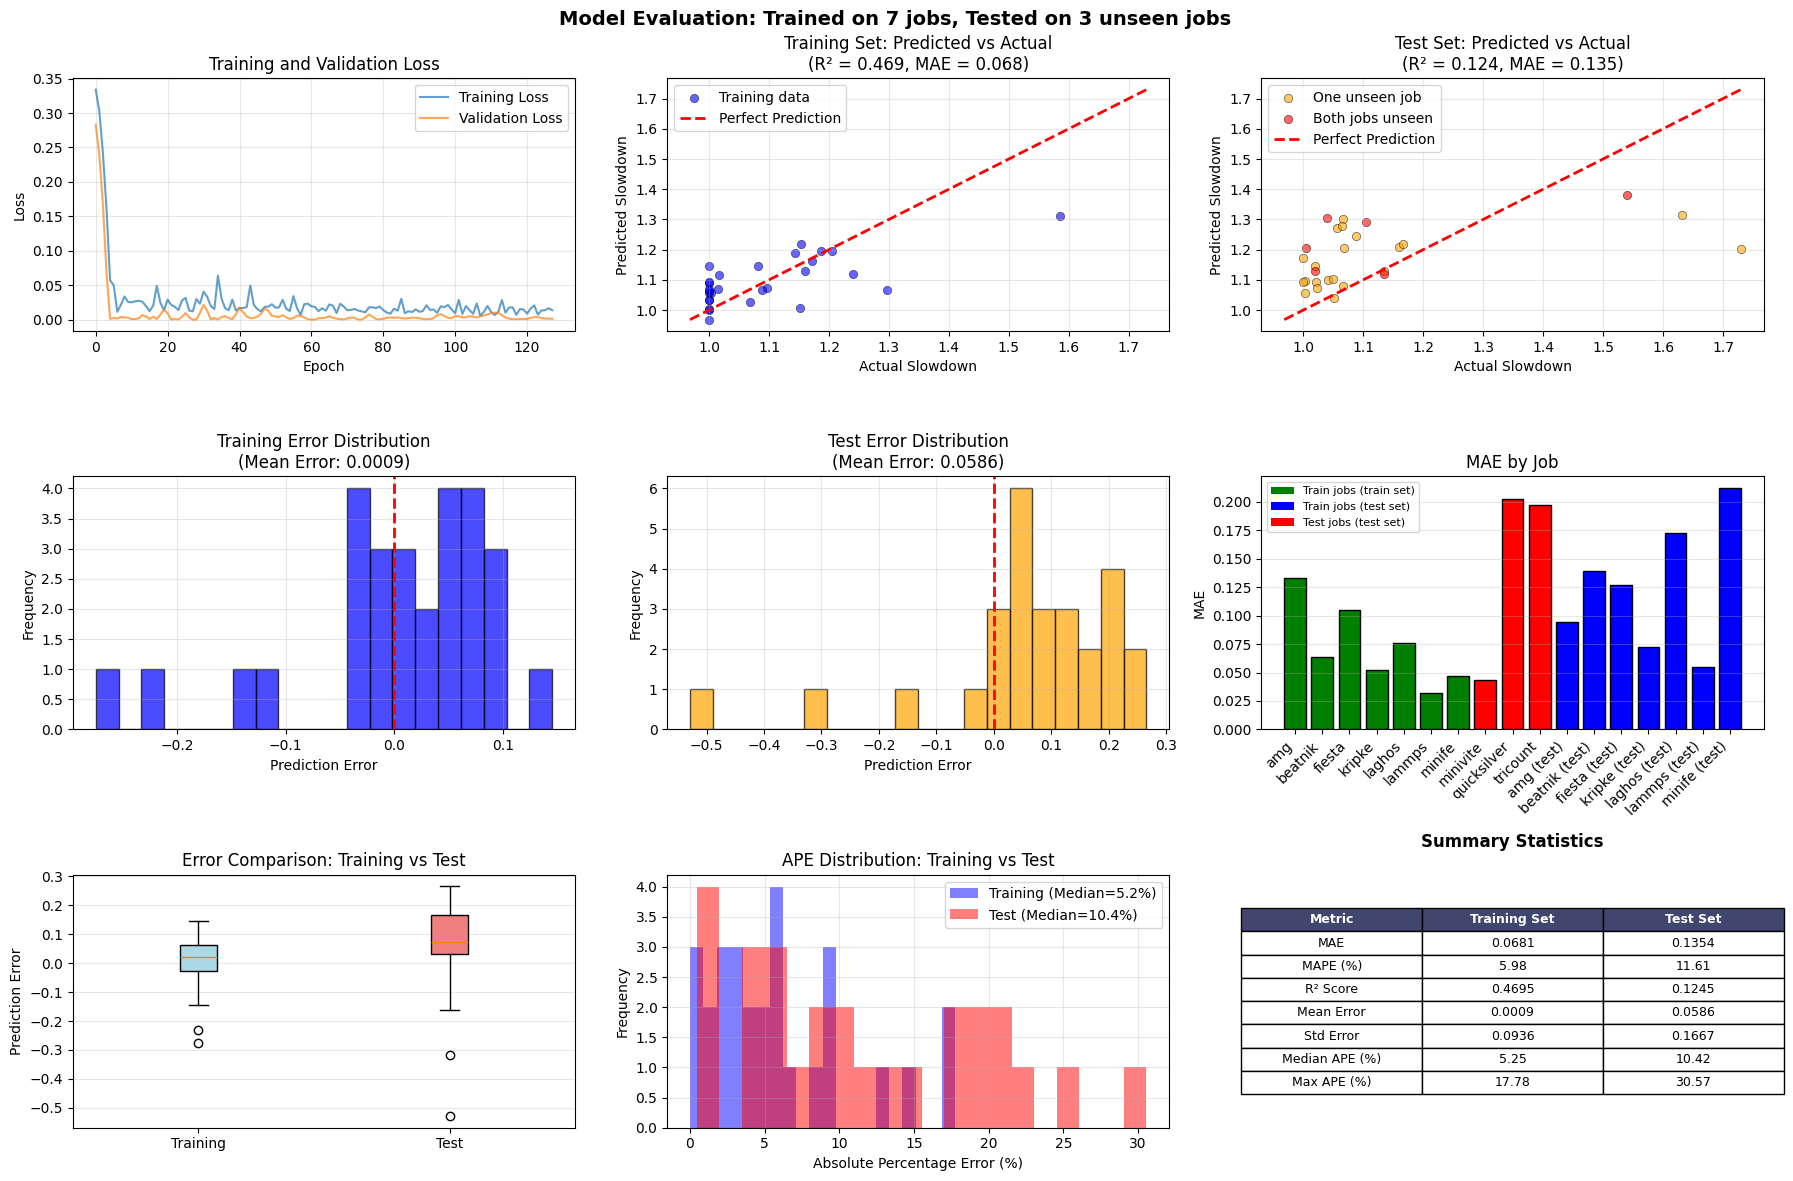

In [9]:
# -----------------------------
# 8. Comprehensive visualization
# -----------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Create a large figure with subplots
fig = plt.figure(figsize=(18, 12))

# 1. Training Loss Curves
ax1 = plt.subplot(3, 3, 1)
ax1.plot(train_losses, label='Training Loss', alpha=0.7)
ax1.plot(val_losses, label='Validation Loss', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Training: Predicted vs Actual
ax2 = plt.subplot(3, 3, 2)
ax2.scatter(train_targets, train_preds, alpha=0.6, edgecolors='k', linewidth=0.5, 
            c='blue', label='Training data')
min_val = min(train_targets.min(), train_preds.min(), test_targets.min(), test_preds.min())
max_val = max(train_targets.max(), train_preds.max(), test_targets.max(), test_preds.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Slowdown')
ax2.set_ylabel('Predicted Slowdown')
ax2.set_title(f'Training Set: Predicted vs Actual\n(R² = {r2_train:.3f}, MAE = {train_mae:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Test: Predicted vs Actual
ax3 = plt.subplot(3, 3, 3)
# Color by pair type
if len(one_unseen) > 0:
    ax3.scatter(one_unseen_targets, one_unseen_preds, alpha=0.6, edgecolors='k', 
                linewidth=0.5, c='orange', label='One unseen job')
if len(both_unseen) > 0:
    ax3.scatter(both_unseen_targets, both_unseen_preds, alpha=0.6, edgecolors='k', 
                linewidth=0.5, c='red', label='Both jobs unseen')
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Slowdown')
ax3.set_ylabel('Predicted Slowdown')
ax3.set_title(f'Test Set: Predicted vs Actual\n(R² = {r2_test:.3f}, MAE = {test_mae:.3f})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Training Error Distribution
ax4 = plt.subplot(3, 3, 4)
train_errors = train_preds.flatten() - train_targets.flatten()
ax4.hist(train_errors, bins=20, edgecolor='black', alpha=0.7, color='blue')
ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Prediction Error')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Training Error Distribution\n(Mean Error: {np.mean(train_errors):.4f})')
ax4.grid(True, alpha=0.3)

# 5. Test Error Distribution
ax5 = plt.subplot(3, 3, 5)
test_errors = test_preds.flatten() - test_targets.flatten()
ax5.hist(test_errors, bins=20, edgecolor='black', alpha=0.7, color='orange')
ax5.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax5.set_xlabel('Prediction Error')
ax5.set_ylabel('Frequency')
ax5.set_title(f'Test Error Distribution\n(Mean Error: {np.mean(test_errors):.4f})')
ax5.grid(True, alpha=0.3)

# 6. Performance by job (training jobs vs test jobs)
ax6 = plt.subplot(3, 3, 6)
job_performance = {}
all_jobs_for_plot = []

# Training jobs performance on training set
for job_id in train_job_ids:
    job_pairs = train_results_df[train_results_df["jobA_id"] == job_id]
    if len(job_pairs) > 0:
        mae = np.mean(np.abs(job_pairs['predicted_slowdown'] - job_pairs['actual_slowdown']))
        job_performance[job_id] = {'mae': mae, 'type': 'Train Job (on train set)'}
        all_jobs_for_plot.append(job_id)

# Test jobs performance on test set
for job_id in test_job_ids:
    job_pairs = test_results_df[test_results_df["jobA_id"] == job_id]
    if len(job_pairs) > 0:
        mae = np.mean(np.abs(job_pairs['predicted_slowdown'] - job_pairs['actual_slowdown']))
        job_performance[job_id] = {'mae': mae, 'type': 'Test Job (on test set)'}
        all_jobs_for_plot.append(job_id)

# Also evaluate training jobs on test set (where they appear with unseen jobs)
train_jobs_test_pairs = test_results_df[test_results_df["jobA_id"].isin(train_job_ids)]
for job_id in train_job_ids:
    job_pairs = train_jobs_test_pairs[train_jobs_test_pairs["jobA_id"] == job_id]
    if len(job_pairs) > 0:
        mae = np.mean(np.abs(job_pairs['predicted_slowdown'] - job_pairs['actual_slowdown']))
        # Add as separate entry or update
        all_jobs_for_plot.append(f"{job_id} (test)")
        job_performance[f"{job_id} (test)"] = {'mae': mae, 'type': 'Train Job (on test set)'}

# Plot
unique_jobs = all_jobs_for_plot
mae_values = [job_performance[j]['mae'] for j in unique_jobs]
colors = []
for j in unique_jobs:
    if job_performance[j]['type'] == 'Train Job (on train set)':
        colors.append('green')
    elif job_performance[j]['type'] == 'Train Job (on test set)':
        colors.append('blue')
    else:
        colors.append('red')

bars = ax6.bar(range(len(unique_jobs)), mae_values, color=colors, edgecolor='black')
ax6.set_xticks(range(len(unique_jobs)))
ax6.set_xticklabels(unique_jobs, rotation=45, ha='right')
ax6.set_ylabel('MAE')
ax6.set_title('MAE by Job')
ax6.grid(True, alpha=0.3, axis='y')

legend_elements = [
    Patch(facecolor='green', label='Train jobs (train set)'),
    Patch(facecolor='blue', label='Train jobs (test set)'),
    Patch(facecolor='red', label='Test jobs (test set)')
]
ax6.legend(handles=legend_elements, fontsize=8)

# 7. Error comparison box plot
ax7 = plt.subplot(3, 3, 7)
data_to_plot = [train_errors, test_errors]
bp = ax7.boxplot(data_to_plot, labels=['Training', 'Test'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax7.set_ylabel('Prediction Error')
ax7.set_title('Error Comparison: Training vs Test')
ax7.grid(True, alpha=0.3, axis='y')

# 8. Absolute percentage error comparison
ax8 = plt.subplot(3, 3, 8)
train_ape = np.abs(train_errors / (train_targets.flatten() + 1e-8)) * 100
test_ape = np.abs(test_errors / (test_targets.flatten() + 1e-8)) * 100
ax8.hist(train_ape, bins=20, alpha=0.5, label=f'Training (Median={np.median(train_ape):.1f}%)', color='blue')
ax8.hist(test_ape, bins=20, alpha=0.5, label=f'Test (Median={np.median(test_ape):.1f}%)', color='red')
ax8.set_xlabel('Absolute Percentage Error (%)')
ax8.set_ylabel('Frequency')
ax8.set_title('APE Distribution: Training vs Test')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Summary statistics table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

summary_data = [
    ['Metric', 'Training Set', 'Test Set'],
    ['MAE', f'{train_mae:.4f}', f'{test_mae:.4f}'],
    ['MAPE (%)', f'{train_mape:.2f}', f'{test_mape:.2f}'],
    ['R² Score', f'{r2_train:.4f}', f'{r2_test:.4f}'],
    ['Mean Error', f'{np.mean(train_errors):.4f}', f'{np.mean(test_errors):.4f}'],
    ['Std Error', f'{np.std(train_errors):.4f}', f'{np.std(test_errors):.4f}'],
    ['Median APE (%)', f'{np.median(train_ape):.2f}', f'{np.median(test_ape):.2f}'],
    ['Max APE (%)', f'{np.max(train_ape):.2f}', f'{np.max(test_ape):.2f}'],
]

table = ax9.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
# Color the header
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax9.set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.suptitle(f'Model Evaluation: Trained on {len(train_job_ids)} jobs, Tested on {len(test_job_ids)} unseen jobs',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
# plt.savefig('model_evaluation_detailed.png', dpi=150, bbox_inches='tight')
plt.show()